In [ ]:
import re; pattern = re.compile('[^a-zA-Z0-9_ ]+')
strip_punct = lambda s: pattern.sub('', s)
tokenize = lambda text: strip_punct(text.lower()).strip().split()
import os 
from pathlib import Path
from collections import Counter
from tqdm import tqdm
import math
import json
import pandas as pd
import pickle
from time import time
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D
from locations import *

In [ ]:
n_topics = [2,3,4,5]

# ----- load topviews data -----------------------------------------------------

topviews = pd.read_csv(path_data / "topviews" / "topviews-2025.csv").iloc[:10]
topviews = topviews[~topviews.duplicated('Page')]

# ----- load BLP data; they also determine our topic-modeling vocab ------------

blp_item = pd.read_csv(path_blp / 'blp-items.txt', sep='\t', na_values=['NA'], keep_default_na=False)
blp_stim = pd.read_csv(path_blp / 'blp-stimuli.txt', sep='\t', na_values=['NA'], keep_default_na=False)
vocab = blp_item[(blp_item.lexicality=='W') & np.isfinite(blp_item.zscore)].spelling.tolist()
vocab_set = set(vocab)

# ---------- load SWOW data ----------------------------------------------------

swow = pd.read_csv(path_swow / 'responseStats.SWOW-EN.20180827.csv')
swow = swow.set_index('response')
swow = swow.fillna(0)
swow.index = swow.index.str.lower()
swow_set = set(swow.index.tolist())
swow = swow[swow.columns[swow.columns.str.contains('Freq')]]
swow.columns = swow.columns.str.replace('.', '_')
swow.columns = swow.columns.str.lower()
swow = swow.groupby(level=0).sum()
shared_index = [word for word in vocab if word in swow_set]
swow = swow.loc[shared_index]
swow.loc[~np.isfinite(swow['freq_r1']), 'freq_r1'] = 0.0
swow.loc[~np.isfinite(swow['freq_r123']), 'freq_r123'] = 0.0
swow['freq_r1'] += 1
swow['freq_r123'] += 1
swow['freq_r123'] = swow['freq_r123'].astype(float)
swow['log_freq_1'] = np.log10(swow['freq_r1'])
swow['log_freq_123'] = np.log10(swow['freq_r123'])

## 1. building the topic models

In [9]:
# ---------------- few helper functions for text processing --------------------

strip_punct = lambda s: pattern.sub('', s)
tokenize = lambda text: strip_punct(text.lower()).strip().split()
list_text_files = lambda dataset_path: list(Path(dataset_path).rglob("*.txt"))

def read_text_files(file_paths, max_size=None): 
    """ reads the files specified with file_paths into a list of strings; normalizes by lowercasing and stripping punctuation """
    docs = []
    size_so_far = 0
    for fpath in file_paths: 
        with open(fpath) as f: 
            docs.append(' '.join(tokenize(f.read())))
        size_so_far += len(docs[-1].encode())
        if max_size and size_so_far >= max_size:
            break
    return docs 

def to_camel_case(s: str) -> str:
    """Convert string (with spaces, underscores, hyphens) to camelCase."""
    parts = re.split(r'[\s_-]+', s.strip())
    if not parts:
        return ""
    return parts[0].lower() + "".join(word.capitalize() for word in parts[1:])

def safe_filename(name: str) -> str:
    """Replace unsafe filename characters with underscores."""
    return re.sub(r'[^A-Za-z0-9._-]', '_', name)

def dict_to_filename(data: dict) -> str:
    """Embed dict into a safe filename with camelCase keys and string values camelCased."""
    parts = []
    for k, v in data.items():
        key = to_camel_case(str(k))
        if isinstance(v, str):
            value = to_camel_case(v)
        else:
            value = str(v)
        parts.append(f"{key}-{value}")
    filename = "_".join(parts)
    return safe_filename(filename)

# -------------------- helpers for topic modeling ------------------------------
def tm_plot_top_words(model, feature_names, n_top_words, title):
    grid_side = int(math.ceil(math.sqrt(len(model.components_))))
    fig, axes = plt.subplots(grid_side, grid_side, figsize=(grid_side*5, grid_side*5), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    return fig, axes

def fit_tm(train_docs_vect, vectorizer, model_class, hp_static, hp_dyn, prefix, analysis_path, overwrite_if_exists=False):
    model_desc = prefix + '_' + dict_to_filename(hp_dyn)
    if os.path.isdir(f'{analysis_path}/topic_models/{model_desc}/model.pkl') and not overwrite_if_exists:
        print(f'found a file at {f'{analysis_path}/topic_models/{model_desc}/model.pkl'}, skipping')
        return
    t0 = time()
    print(f'fitting model: {model_desc}...')
    model = model_class(**hp_static, **hp_dyn).fit(train_docs_vect)
    print(f'done in {time()-t0}s')
    fig, _ = plot_top_words(model, vectorizer.get_feature_names_out(), n_top_words=15, title=model_desc)
    os.makedirs(f'{analysis_path}/topic_models/{model_desc}', exist_ok=True)
    with open(f'{analysis_path}/topic_models/{model_desc}/model.pkl', 'wb') as f: 
        pickle.dump(model, f)
    with open(f'{analysis_path}/topic_models/{model_desc}/vectorizer.pkl', 'wb') as f: 
        pickle.dump(vectorizer, f)
    fig.savefig(f'{analysis_path}/topic_models/{model_desc}/topics.png')
    plt.close()
    with open(f'{analysis_path}/topic_models/{model_desc}/model.hyperparams.json', 'w') as f: 
        json.dump(hp_dyn | hp_static, f)

def load_tm(topic_model):
    with open(f'{topic_model}/model.pkl', 'rb') as f: 
        model = pickle.load(f)
    with open(f'{topic_model}/vectorizer.pkl', 'rb') as f: 
        vectorizer = pickle.load(f)
    return model, vectorizer

# ------------------ our "main run" function -----------------------------------
def create_analysis(dataset: Path, n_topics: list | int, random_seed: int, max_size: int | None = None, overwrite_if_exists: bool = False): 
    """Creates an analysis (under a new directory at data/analysis/<generated_analysis_name>). 
    This entails training and saving topic models with the specifies number of topics under n_topics,
    the text vectorizer, and a frequency list. 

    Args:
        dataset (Path): a directory under which there are text file to be used as training corpus
        n_topics (list | int): number of topics
        random_seed (int): random seed
        max_size (int | None, optional): if not None, the file loader for the training corpus will stop when reaching max_size bytes. Defaults to None.
        overwrite_if_exists (bool, optional): Overwrite analysis if there is one under this specification already. Defaults to False.
    """
    analysis_name = dict_to_filename(dict(dataset=str(dataset.parts[-1]), random_seed=random_seed, max_size=max_size))
    this_analysis_path = path_analysis / analysis_name
    if this_analysis_path.exists(): 
        print(f"found an existing analysis at {str(this_analysis_path)}, skipping")
        return analysis_name

    print(f"creating a new analysis at {str(this_analysis_path)}")
    this_analysis_path.mkdir(exist_ok=True)
    files = list_text_files(dataset)
    print("reading documents...")
    train_docs = read_text_files(files, max_size=max_size)
    print(f'found {sum(map(lambda d: len(d.encode()), train_docs))/1000000:.3f} MB of data')

    # topic modeling hyper parameters (with sklearn's lda)
    hp_static = dict(
        random_state = random_seed,
        n_jobs=-1,
        learning_method='online', 
        batch_size=2000,
        learning_decay=0.7, 
        learning_offset=10.0,
        max_iter=20,
    )

    # create and save a (count-) text vectorizer
    vectorizer = CountVectorizer(input='content', vocabulary=vocab, tokenizer=str.split)
    train_docs_vect = vectorizer.fit_transform(train_docs)
    with (this_analysis_path / 'vectorizer.pkl').open('wb') as f: 
        pickle.dump(vectorizer, f)

    # loop over the topic number settings, train and save a topic model for each
    if isinstance(n_topics, int): 
        n_topics = [n_topics]
    for hp_dyn in [dict(n_components=n) for n in n_topics]:
        fit_tm(train_docs_vect, 
                vectorizer=vectorizer, 
                model_class=LatentDirichletAllocation, 
                hp_static=hp_static,
                hp_dyn=hp_dyn, 
                prefix=f'lda', 
                analysis_path=str(this_analysis_path),
                overwrite_if_exists=overwrite_if_exists)
    
    # create and save a frequency list
    counts = Counter()
    print('creating a frequency list...')
    for doc in tqdm(train_docs):
        tokens = [tok for tok in doc.split() if tok in vocab_set]
        counts += Counter(tokens)
    with (this_analysis_path / 'freq.pkl').open('wb') as f: 
        pickle.dump(counts, f)
    return analysis_name

def load_analysis(analysis_name): 
    this_analysis_path = path_analysis / analysis_name
    with (this_analysis_path / 'freq.pkl').open('rb') as f: 
        counts = pickle.load(f)
    with (this_analysis_path / 'vectorizer.pkl').open('rb') as f: 
        vectorizer = pickle.load(f)
    with (this_analysis_path / 'corpus_docs.pkl').open('rb') as f: 
        files = pickle.load(f)
    models = {}
    # for model_dir in os.listdir(os.path.join(this_analysis_path, 'topic_models')):
    for model_dir in os.listdir(this_analysis_path / 'topic_models'):
        models[model_dir] = load_tm((this_analysis_path / 'topic_models' / model_dir))
    return this_analysis_path, counts, vectorizer, files, models


## 2. collecting results

In [ ]:
# --------- these lines run the topic modeling analysis ------------------------
analyses = [
    create_analysis(path_wikipedia, n_topics=n_topics, random_seed=754),
    create_analysis(path_subtitles, n_topics=n_topics, random_seed=754),
]

In [ ]:
def plot_zipf(model_and_vectorizer): 
    model, _ = model_and_vectorizer
    dist = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    for comp in range(dist.shape[0]):
        plt.plot(sorted(dist[comp], reverse=True))
    plt.yscale('log')
    plt.xscale('log')

def print_differential_words(model_and_vectorizer, topic_n, top_features=100): 
    model, vectorizer = model_and_vectorizer
    ranks_mean = model.components_.mean(0).argsort()[::-1].argsort()+1
    ranks_diff = []
    ranks = []
    for topic_idx, topic in enumerate(model.components_):
        _ranks = topic.argsort()[::-1].argsort()+1
        _diff = (ranks_mean-_ranks)/ranks_mean
        ranks_diff.append((_diff*100).round(2))
        ranks.append(_ranks)
    risers_and_sinkers = ranks_diff[topic_n].argsort()
    risers = risers_and_sinkers[-top_features:][::-1]
    feature_names = vectorizer.get_feature_names_out()
    riser_words = feature_names[risers]
    riser_diffs = ranks_diff[topic_n][risers].tolist()
    riser_ranks = ranks[topic_n][risers].tolist()

    for word, diff, rank in zip(riser_words, riser_diffs, riser_ranks):
        print(f"word: {word}\trank: {rank}\tdiff: {diff}%\t")

def create_dataframe(model_and_vectorizer, counts): 
    subset = blp_item[(blp_item.lexicality=='W') & np.isfinite(blp_item.zscore)].copy()
    subset.set_index('spelling', inplace=True)
    subtlex_stats = blp_stim.set_index('spelling').loc[subset.index, blp_stim.columns[blp_stim.columns.str.startswith('subtlex')]]
    subset = subset.join(subtlex_stats)
    subset['subtlex.frequency'] += 1
    subset.columns = subset.columns.str.replace('.', '_')
    freq_ttl = [counts.get(word, 0)+1 for word in subset.index]
    freq_ttl = np.array(freq_ttl)+1
    model, vectorizer = model_and_vectorizer
    assert (vectorizer.get_feature_names_out() != subset.index.to_numpy()).sum() == 0
    dist = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    subset['freq'] = freq_ttl
    subset['proba_mean'] = dist.mean(axis=0)
    for i in range(dist.shape[0]): 
        subset[f'proba_{i}'] = dist[i]
    # components = [f'np.log(proba_{i})' for i in range(dist.shape[0])]
    components = [f'np.log(proba_{i})' for i in range(dist.shape[0])]
    formulas = {
        'lda': 'zscore ~ '+' + '.join(components),
        'freq': 'zscore ~ np.log(freq)',
        'lda_mean': 'zscore ~ np.log(proba_mean)',
        'subtlex': 'zscore ~ np.log(subtlex_frequency)',
    }
    return subset, formulas, dist

### 2a. collect results for Topviews

In [ ]:
def get_topviews_freq(vectorizer, topviews_selection, flatten=True):
    fnames = []
    for page in topviews_selection: 
        fname = path_data / 'topviews' / 'wiki-articles' / (page.replace(' ', '_')+'.txt')
        if os.path.isfile(fname): fnames.append(fname)
    docs = read_text_files(fnames)
    # print(f'found {len(docs)} docs')
    topviews_freq = vectorizer.transform(docs).toarray().astype(float)
    if flatten: 
        topviews_freq = topviews_freq.sum(axis=0).flatten()
    return topviews_freq

def get_topviews_rsquared(topviews_selection, model_and_vectorizer, counts, strategy): 
    model, vectorizer = model_and_vectorizer
    topviews_freq = get_topviews_freq(vectorizer, topviews_selection, False)
    cd = (topviews_freq>0).sum(axis=0) / topviews_freq.shape[0]
    topviews_freq = topviews_freq.sum(axis=0)

    df_full, formulas, dist = create_dataframe(model_and_vectorizer, counts)
    df = df_full.copy()
    df['topviews'] = topviews_freq

    if strategy == 'smoothing':
        df.topviews += 1e-3
    else: 
        df = df[df.topviews > 0]
    df.topviews = np.log10(df.topviews)
    if len(df) == 0: 
        return {'lda_topviews': 0}

    result = {'pages': topviews_selection}
    formula = formulas['lda'].replace('zscore', 'topviews')
    result_ols = smf.ols(formula, data=df).fit()
    coef_topviews = result_ols.params[1:]

    result_ols = smf.ols(formulas['lda'], data=df_full).fit()
    # print(f"formula: {result_ols.model.formula}")
    # print(f"r^2: {result_ols.rsquared_adj:.4f}")
    coef_rts = result_ols.params[1:]
    result['lda'] = result_ols.rsquared_adj

    result_ols = smf.ols(formulas['freq'], data=df_full).fit()
    # print(f"formula: {result_ols.model.formula}")
    # print(f"r^2: {result_ols.rsquared_adj:.4f}")
    result['freq'] = result_ols.rsquared_adj

    df_full['log_lda_topviews'] = (np.log(dist) * coef_topviews.to_numpy().reshape((-1, 1))).sum(axis=0)
    result_ols = smf.ols("zscore ~ log_lda_topviews", data=df_full).fit()
    # print(f"formula: {result_ols.model.formula}")
    # print(f"r^2: {result_ols.rsquared_adj:.4f}")
    result['lda_topviews'] = result_ols.rsquared_adj
    return result

_results = []
for analysis in analyses: 
    analysis_path, counts, vectorizer, files, models = load_analysis(analysis)
    for n_comp in n_topics:
        model_and_vectorizer = models[f'lda_nComponents-{n_comp}']
        for title in topviews.Page: 
            result = get_topviews_rsquared([title], model_and_vectorizer, counts, 'smoothing')
            result['pages'] = result['pages'][0]
            _results.append(dict(n_comp=n_comp, corpus=analysis) | result)
_results = pd.DataFrame(_results).round(5)
_results.to_csv('results/results_topviews.csv')

### 2b. collect results for SWOW

In [ ]:
sizes = (2 ** np.arange(4,14)).tolist() + [len(swow)]
_results = []
nsim = 30

for analysis in analyses: 
    analysis_path, counts, vectorizer, files, models = load_analysis(analysis)
    for n_comp in n_topics:
        model_and_vectorizer = models[f'lda_nComponents-{n_comp}']
        df_full, formulas, dist = create_dataframe(model_and_vectorizer, counts)
        df = df_full.copy().loc[shared_index]
        df = df.join(swow)
        assert (df.index != swow.index).sum()==0
        
        for sim_i in range(nsim):
            for size in sizes: 
                result = {'sim': sim_i}
                formula = formulas['lda'].replace('zscore', 'log_freq_1')
                result_ols = smf.ols(formula, data=df.sample(size)).fit()
                coef = result_ols.params[1:]
                result_ols = smf.ols(formulas['lda'], data=df_full).fit()
                result['lda'] = result_ols.rsquared_adj
                result_ols = smf.ols(formulas['freq'], data=df_full).fit()
                result['freq'] = result_ols.rsquared_adj
                df_full['lda_log_freq_1'] = (np.log(dist) * coef.to_numpy().reshape((-1, 1))).sum(axis=0)
                result_ols = smf.ols("zscore ~ lda_log_freq_1", data=df_full).fit()
                result['lda_log_freq_1'] = result_ols.rsquared_adj
                result = result | dict(corpus=analysis, n_comp=n_comp, size=size)
                _results.append(result)

_results = pd.DataFrame(_results).round(5)
_results['delta'] = _results.lda_log_freq_1 - _results.freq
_results['delta_max'] = _results.lda - _results.freq
_results.to_csv('results/results_swow.csv')

## 3. visualize results

In [ ]:
results_swow = pd.read_csv('results/results_swow.csv', index_col=0)
agg = results_swow.groupby(['analysis', 'n_comp', 'size'])[['lda', 'lda_log_freq_1', 'freq']].agg(['mean', 'std']).reset_index()
results_topviews = pd.read_csv('results/results_topviews.csv', index_col=0)

In [129]:
analyses = [
    create_analysis(path_wikipedia, n_topics=n_topics, random_seed=754),
    create_analysis(path_subtitles, n_topics=n_topics, random_seed=754),
]

found an existing analysis at data/analysis/dataset-wikipedia_randomSeed-754_maxSize-None, skipping
found an existing analysis at data/analysis/dataset-opensubtitles_randomSeed-754_maxSize-None, skipping


<>:44: SyntaxWarning: invalid escape sequence '\%'
<>:44: SyntaxWarning: invalid escape sequence '\%'
/var/folders/n_/nb0nr2sd6_925f9251v_rm_w0000gn/T/ipykernel_3551/3533138084.py:44: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel(f"{ylabel}\n$\%R^2$")


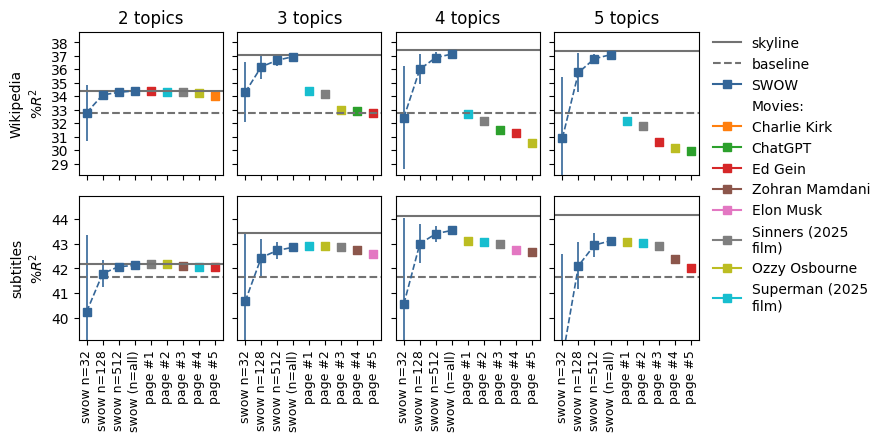

In [142]:
fig, axes = plt.subplots(nrows=len(analyses), ncols=len(n_topics), figsize=(8, 4), sharex=True, )
fig.subplots_adjust(wspace=.1, hspace=.15)

axes = iter(axes.flatten())

colors = dict(zip(topviews.Page, plt.cm.tab10.colors))
color_swow = "#346698"
pages_included = set()

for analysis, ylabel in zip(analyses, ['Wikipedia', 'subtitles']):
    for n_comp in n_topics:
        ax = next(axes)
        subset_swow = results_swow[(results_swow.n_comp==n_comp)&(results_swow.analysis==analysis)]
        swow_points = subset_swow.groupby(['size'])['lda_log_freq_1'].agg(['mean', 'std'])
        sizes = [32, 128, 512, len(swow)]
        ax.errorbar(np.arange(len(sizes)), swow_points.loc[sizes]['mean'], yerr=swow_points.loc[sizes]['std'], linestyle='--', linewidth=1.2, marker='s', color=color_swow)

        subset_topviews = results_topviews[(results_topviews.n_comp==n_comp)&(results_topviews.analysis==analysis)]
        n=5
        topn = subset_topviews.sort_values('lda_topviews', ascending=False).iloc[:n]
        pages_included.update(topn.pages.tolist())
        x_offset = len(sizes)
        for i, row in topn.iterrows(): 
            ax.scatter(x_offset, row.lda_topviews, marker='s', label=row.pages, color=colors[row.pages])
            x_offset += 1

        ax.set_xticks(ticks=np.arange(len(sizes)+n), labels=[f'swow n={s}' for s in sizes[:-1]] + ["swow (n=all)"] + [f"page #{i+1}" for i in range(n)], rotation=90, fontsize=9)
        xlim = [-.5,n+len(sizes)-.5]
        ceiling_val = subset_swow.lda.iloc[0]
        baseline_val = subset_swow.freq.iloc[0]
        ax.plot(xlim, [ceiling_val]*2, label='skyline', linewidth=1.5, c="#727272")
        ax.plot(xlim, [baseline_val]*2, label='baseline', linewidth=1.5, c="#727272", linestyle='--')
        ax.set_xlim(xlim)
        ceiling_corpus = results_topviews[results_topviews.analysis==analysis].lda.max()
        baseline_corpus = results_topviews[results_topviews.analysis==analysis].freq.max()
        ylim = (min(baseline_corpus-1.0*(ceiling_corpus-baseline_corpus), topn.lda_topviews.min()-.01), 
                ceiling_corpus+.3*(ceiling_corpus-baseline_corpus))
        yticks = np.arange(np.ceil(ylim[0]*100), np.ceil(ylim[1]*100), step=1)/100
        ax.set_yticks(yticks, labels=[f'{yt*100:.0f}' for yt in yticks])
        ax.set_ylim(ylim)
        if n_comp>2: 
            ax.set_yticklabels([])
        if n_comp==2:
            ax.set_ylabel(f"{ylabel}\n$\%R^2$")
        if analysis == analyses[0]: 
            ax.set_title(f"{n_comp} topics")

# fig.tight_layout()
handles, labels = ax.get_legend_handles_labels()
handles = handles[-2:]
labels = labels[-2:]
handles.append(Line2D([0],[0], marker='s', color=color_swow))
labels.append('SWOW')
blank_handle = mpatches.Rectangle((0, 0), 1, 1, fill=False, edgecolor='none', visible=False)
handles.append(blank_handle); labels.append('Movies:')
# handles.append(blank_handle); labels.append('Movies:')
for page, clr in colors.items(): 
    if page not in pages_included: continue
    handles.append(Line2D([0], [0], marker='s', color=clr))
    labels.append(textwrap.fill(page, width=15))
fig.legend(handles, labels, loc='upper right', ncol=1, bbox_to_anchor=(1.13,.9), frameon=False)
fig.savefig('results.pdf', format='pdf',  bbox_inches='tight')